# Bagging and Random Forest

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# load dataset
def load_heart_data():
  url = "heart.csv"
  df = pd.read_csv(url)
  return df

df = load_heart_data()
print("Shape:", df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


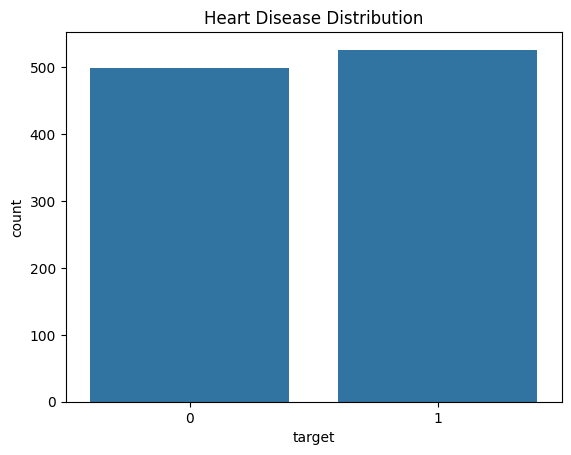

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
# split Data
def split_data(df):
  X = df.drop("target", axis=1)
  y= df['target']
  return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = split_data(df)

In [ ]:
# Random Forest
def train_random_forest(X_train, X_test, y_train, y_test):
  rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
  rf.fit(X_train, y_train)
  preds = rf.predict(X_test)
  acc = accuracy_score(y_test, preds)
  return acc, preds

rf_acc, rf_preds = train_random_forest(X_train, X_test, y_train, y_test)
print("Random Forest Accuracy: ", rf_acc)

Random Forest Accuracy:  0.926829268292683


In [ ]:
rf_preds

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1])

In [ ]:
# Train custom bagger
from sklearn.utils import resample
from scipy.stats import mode

def bagger_fit_predict(model_fns, X_train, y_train, X_test, n_estimators=15):
  all_preds = []
  for fn in model_fns:
    for _ in range(n_estimators):
      # bootstrap sample
      X_bs, y_bs = resample(X_train, y_train, replace=True)
      # build model
      model = fn()
      # fit model
      model.fit(X_bs, y_bs)
      # predict
      preds = model.predict(X_test)
      all_preds.append(preds)
  all_preds = np.array(all_preds)
  final_preds = mode(all_preds, axis=0).mode
  return final_preds.ravel()


# ------ Bagging ensemble -------
model_list = [
    lambda: DecisionTreeClassifier(max_depth=5),
    lambda: KNeighborsClassifier(n_neighbors=5),
    lambda: LogisticRegression(max_iter=50)
]

bagger_preds = bagger_fit_predict(
    model_fns=model_list,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    n_estimators=15
)
bagger_acc = accuracy_score(y_test, bagger_preds)
print("Custom Bagger Accuracy: ", bagger_acc)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Custom Bagger Accuracy:  0.8878048780487805


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

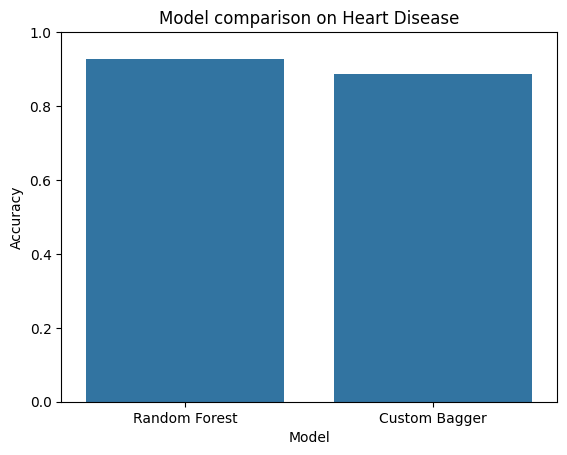

,Model,Accuracy
0,Random Forest,0.926829
1,Custom Bagger,0.887805


In [ ]:
# compare all models

results = pd.DataFrame({
    "Model": ["Random Forest", "Custom Bagger"],
    "Accuracy": [rf_acc, bagger_acc]
})

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model comparison on Heart Disease")
plt.ylim(0, 1)
plt.show()

results

In [ ]:
print ("Classification Report (custom Bagger): ")
print(classification_report(y_test, bagger_preds))

Classification Report (custom Bagger): 
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       100
           1       0.86      0.93      0.89       105

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



In [ ]:
# Voting Method

from sklearn.ensemble import VotingClassifier

voting_ensemble = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5)),
        ('knn', KNeighborsClassifier(n_neighbors=3))
    ],
    voting='soft'
)
voting_ensemble.fit(X_train, y_train)
print("Voting Ensemble Accuracy: ", voting_ensemble.score(X_test, y_test))


Voting Ensemble Accuracy:  0.926829268292683
